### **Business Problem:**
The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the company, to provide a better recommendation of the treadmills to the new customers. 
The team decides to investigate whether there are differences across the product with respect to customer characteristics.

- Perform descriptive analytics to create a customer profile for each AeroFit treadmill product by developing appropriate tables and charts.
- For each AeroFit treadmill product, construct two-way contingency tables and compute all conditional and marginal probabilities along with their insights/impact on the business.

In [304]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Basic Metrics:

In [305]:
df_aerofit = pd.read_csv('C:\\Users\\njain121\\Desktop\\Scalar\\CaseStudy\\New folder\\aerofit_treadmill.csv')
df_aerofit.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [306]:
df.shape

(180, 9)

In [307]:
df_aerofit.info()  ## details of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [308]:
## sales per product
conditions = [(df_aerofit['Product'] == 'KP281'),(df_aerofit['Product'] == 'KP481'),(df_aerofit['Product'] == 'KP781')]
values = [1500, 1750, 2500]
df_aerofit['Sales'] = np.select(conditions, values)
df_aerofit.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Sales
0,KP281,18,Male,14,Single,3,4,29562,112,1500
1,KP281,19,Male,15,Single,2,3,31836,75,1500
2,KP281,19,Female,14,Partnered,4,3,30699,66,1500
3,KP281,19,Male,12,Single,3,3,32973,85,1500
4,KP281,20,Male,13,Partnered,4,2,35247,47,1500


In [309]:
df_aerofit.describe(include='all')

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Sales
count,180,180.000000,180,180.000000,180,180.000000,180.000000,180.000000,180.000000,180.000000
unique,3,NaN,2,NaN,2,NaN,NaN,NaN,NaN,NaN
top,KP281,NaN,Male,NaN,Partnered,NaN,NaN,NaN,NaN,NaN
freq,80,NaN,104,NaN,107,NaN,NaN,NaN,NaN,NaN
mean,NaN,28.788889,NaN,15.572222,NaN,3.455556,3.311111,53719.577778,103.194444,1805.555556
std,NaN,6.943498,NaN,1.617055,NaN,1.084797,0.958869,16506.684226,51.863605,387.978895
min,NaN,18.000000,NaN,12.000000,NaN,2.000000,1.000000,29562.000000,21.000000,1500.000000
25%,NaN,24.000000,NaN,14.000000,NaN,3.000000,3.000000,44058.750000,66.000000,1500.000000
50%,NaN,26.000000,NaN,16.000000,NaN,3.000000,3.000000,50596.500000,94.000000,1750.000000
75%,NaN,33.000000,NaN,16.000000,NaN,4.000000,4.000000,58668.000000,114.750000,1750.000000


In [310]:
df_aerofit.isna() ##Check for the missing values

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Sales
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
175,False,False,False,False,False,False,False,False,False,False
176,False,False,False,False,False,False,False,False,False,False
177,False,False,False,False,False,False,False,False,False,False
178,False,False,False,False,False,False,False,False,False,False


In [311]:
products_counts = df_aerofit.groupby('Product').size()  ## count per product
products_counts

Product
KP281    80
KP481    60
KP781    40
dtype: int64

In [312]:
## sales per product
sales_per_prd = df_aerofit.groupby('Product').agg(sum).reset_index()
sales_per_prd[['Product','Sales']]

C:\Users\njain121\AppData\Local\Temp\ipykernel_11676\3853701822.py:2: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  sales_per_prd = df_aerofit.groupby('Product').agg(sum).reset_index()


,Product,Sales
0,KP281,120000
1,KP481,105000
2,KP781,100000


In [313]:
## Unique Attributes
df_aerofit.nunique().sort_values(ascending=False)

Income           62
Miles            37
Age              32
Education         8
Usage             6
Fitness           5
Product           3
Sales             3
MaritalStatus     2
Gender            2
dtype: int64

### Outliers Product wise
1. Miles

In [314]:
## 1. Product: KP281
df_KP281 = df_aerofit[df_aerofit['Product'] == 'KP281']
Q1_KP281 = np.percentile(df_KP281['Miles'], 25)
Q3_KP281 = np.percentile(df_KP281['Miles'], 75)
IQR_KP281 = Q3_KP281 - Q1_KP281

# Calculate whiskers
l_whisker = Q1_KP281 - 1.5 * IQR_KP281
u_whisker = Q3_KP281 + 1.5 * IQR_KP281

outliers_KP281 = df_KP281[(df_KP281['Miles'] < l_whisker) | (df_KP281['Miles'] > u_whisker)]

print('Q1_KP281: ', Q1_KP281,'; Q3_KP281: ',  Q3_KP281,'; IQR_KP281: ', IQR_KP281, '; Lower whisker: ',  l_whisker, '; Upper whisker: ',u_whisker)
print()
display(outliers_KP281[['Product', 'Miles']].sort_values(by='Miles',ascending=False).head())

## 2. Product: KP481
df_KP481 = df_aerofit[df_aerofit['Product'] == 'KP481']
Q1_KP481 = np.percentile(df_KP481['Miles'], 25)
Q3_KP481 = np.percentile(df_KP481['Miles'], 75)
IQR_KP481 = Q3_KP481 - Q1_KP481

# Calculate whiskers
l_whisker = Q1_KP481 - 1.5 * IQR_KP481
u_whisker = Q3_KP481 + 1.5 * IQR_KP481

outliers_KP481 = df_KP481[(df_KP481['Miles'] < l_whisker) | (df_KP481['Miles'] > u_whisker)]

print('Q1_KP481: ', Q1_KP481,'; Q3_KP481: ',  Q3_KP481,'; IQR_KP481: ', IQR_KP481, '; Lower whisker: ',  l_whisker, '; Upper whisker: ',u_whisker)
print()
display(outliers_KP481[['Product', 'Miles']].sort_values(by='Miles',ascending=False).head())

## 3. Product: KP781
df_KP781 = df_aerofit[df_aerofit['Product'] == 'KP781']
Q1_KP781 = np.percentile(df_KP781['Miles'], 25)
Q3_KP781 = np.percentile(df_KP781['Miles'], 75)
IQR_KP781 = Q3_KP781 - Q1_KP781

# Calculate whiskers
l_whisker = Q1_KP781 - 1.5 * IQR_KP781
u_whisker = Q3_KP781 + 1.5 * IQR_KP781

outliers_KP781 = df_KP781[(df_KP781['Miles'] < l_whisker) | (df_KP781['Miles'] > u_whisker)]

print('Q1_KP781: ', Q1_KP781,'; Q3_KP781: ',  Q3_KP781,'; IQR_KP781: ', IQR_KP781, '; Lower whisker: ',  l_whisker, '; Upper whisker: ',u_whisker)
print()
display(outliers_KP781[['Product', 'Miles']].sort_values(by='Miles',ascending=False).head())

Q1_KP281:  66.0 ; Q3_KP281:  94.0 ; IQR_KP281:  28.0 ; Lower whisker:  24.0 ; Upper whisker:  136.0



,Product,Miles
23,KP281,188
61,KP281,169
8,KP281,141
53,KP281,141


Q1_KP481:  64.0 ; Q3_KP481:  106.0 ; IQR_KP481:  42.0 ; Lower whisker:  1.0 ; Upper whisker:  169.0



,Product,Miles
84,KP481,212
103,KP481,170
120,KP481,170


Q1_KP781:  120.0 ; Q3_KP781:  200.0 ; IQR_KP781:  80.0 ; Lower whisker:  0.0 ; Upper whisker:  320.0



,Product,Miles
173,KP781,360


Just to makes it clear, two products (like KP281 and KP481) have outliers with the same value, so they are overlapping.

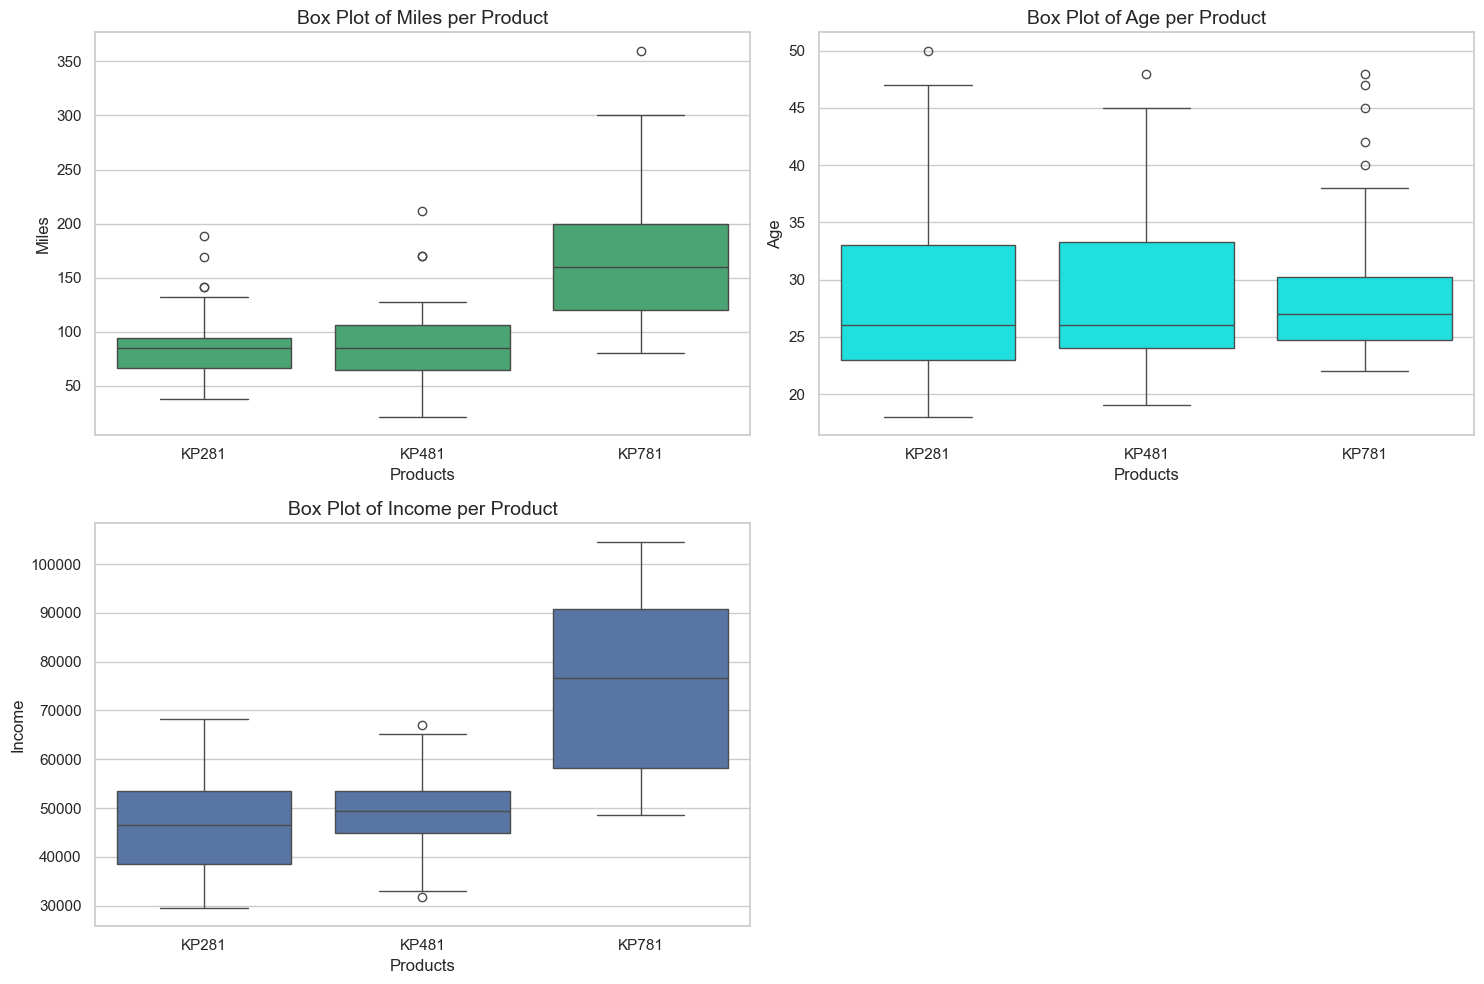

In [315]:
plt.figure(figsize=(15, 10))
plt.subplot(2,2,1)

## Box Plot of Miles per Product
sns.boxplot(data = df_aerofit, x= 'Product', y = 'Miles', color='mediumseagreen')
plt.title('Box Plot of Miles per Product', fontsize=14)
plt.xlabel('Products', fontsize=12)
plt.tight_layout()

## Box Plot of Age per Product
plt.subplot(2,2,2)
sns.boxplot(data = df_aerofit, x= 'Product', y = 'Age', color='cyan')
plt.title('Box Plot of Age per Product', fontsize=14)
plt.xlabel('Products', fontsize=12)
plt.tight_layout()

## Box Plot of Income per Product
plt.subplot(2,2,3)
sns.boxplot(data = df_aerofit, x= 'Product', y = 'Income')
plt.title('Box Plot of Income per Product', fontsize=14)
plt.xlabel('Products', fontsize=12)
plt.tight_layout()
plt.show()

## Key Insights from boxplots:
1. **Miles per Product:**
    - Interpretation
        - KP781 is preferred by more intense users with higher expected mileage.
        - KP281 and KP481 are used by moderate users with similar usage patterns.
        - The spread and outliers suggest KP781 attracts a wider range of high-mileage users.
    - Business Actions:
        - KP781 product appeals to highly active individuals.
        - Market it as a performance or endurance-focused product.
        - Consider partnerships with fitness apps, gyms, or running clubs.
        - Offer features like durability, comfort, or health tracking.

2. **Age per Product:**
    - Interpretation
        - KP781 attracts more to younger customers.
        - KP281 attracts a slightly older age group people with a wider age range.
        - KP481 sits in between but leans closer to KP281 in age distribution.
    - Business Actions:
        - Older users may value comfort, reliability, and ease of use.
        - Younger users may prioritize style, innovation, and affordability.
        - Tailor advertising channels accordingly (e.g., social media for younger, email/newsletters for older).

3. **Income per Product:**
    - Interpretation
        - KP781 is preferred by customer hving higher-income.
        - KP281 is more popular among low to medium income customers.
        - KP481 is opted by mostly a middle-income segment customers.
    - Business Actions:
        - Position product KP781 as a premium one with exclusive features or services.
        - Use luxury branding and target high-income segments for Product KP781.
        - For lower-income segments, emphasize value, affordability, and essential features to sell KP281 and KP481.

C:\Users\njain121\AppData\Local\Temp\ipykernel_11676\3298067049.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_aerofit, x='Product', y='Fitness', palette = 'Set2')


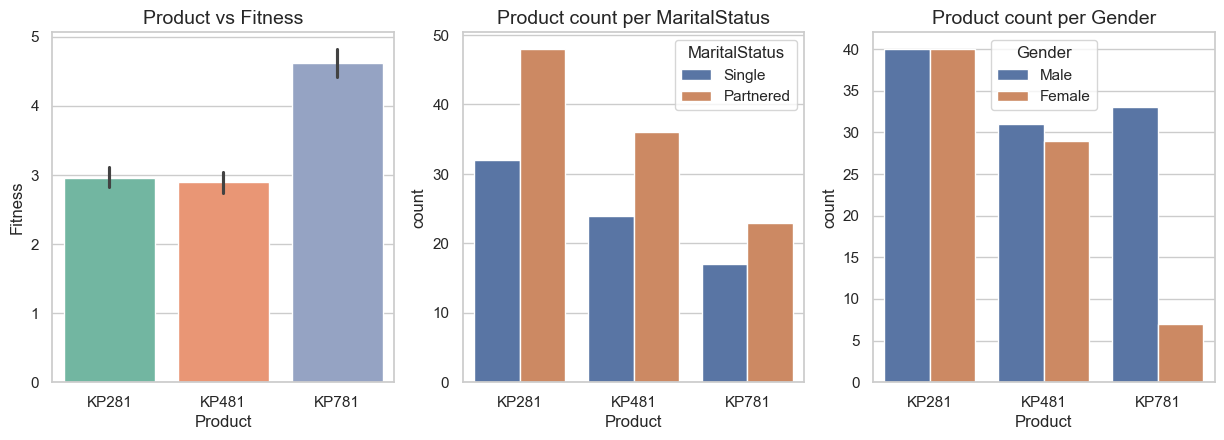

In [316]:
plt.figure(figsize=(15, 10))
plt.subplot(2,3,1)

## Bar Plot Product vs Fitness
sns.barplot(data=df_aerofit, x='Product', y='Fitness', palette = 'Set2')
plt.title('Product vs Fitness', fontsize=14)

## countPlot for Product and Gender
plt.subplot(2,3,3)
sns.countplot(data = df_aerofit, x= 'Product', hue = 'Gender')
plt.title('Product count per Gender', fontsize=14)

## countPlot for Product and Gender
plt.subplot(2,3,2)
sns.countplot(data = df_aerofit, x= 'Product', hue = 'MaritalStatus')
plt.title('Product count per MaritalStatus', fontsize=14)

plt.show()

## Key Insights from barplot and countplots:
1. **Product vs Fitness:**
    - Interpretation
        - KP781 has the highest fitness level, suggesting it performs best in terms of effectiveness or customer satisfaction.
        - KP481 has the lowest fitness level, which may indicate a need for improvement or repositioning.
        - KP281 is in the middle, potentially a balanced option.
    - Business Actions:
        - Promote KP781 as a premium or high-performance product.
        - Investigate KP481 for potential issues—why is it underperforming?
        - Consider customer feedback or product redesign for KP481 to improve its fitness score

2. **Product count per Gender:**
    - Interpretation
        - KP281 is the most popular product across both genders.
        - Males consistently outnumber females in usage across all products.
    - Business Actions:
        - KP281 is gender-neutral in appeal—leverage this in broad campaigns.
        - KP781 again shows a gap between performance and adoption—especially among females. Investigate barriers (e.g., design, communication, accessibility).

3. **Product count per Marital Status:**
    - Interpretation
        - KP281 is popular among both singles and partnered individuals.
        - KP481 has moderate usage, with slightly more singles.
        - KP781 has low usage overall, with a slight skew toward singles.
    - Business Actions:
        - Promote KP781 to partnered individuals with messaging around shared health goals or family wellness.
        - KP281 can be considered as flagship product as it broadly appeals more customers.

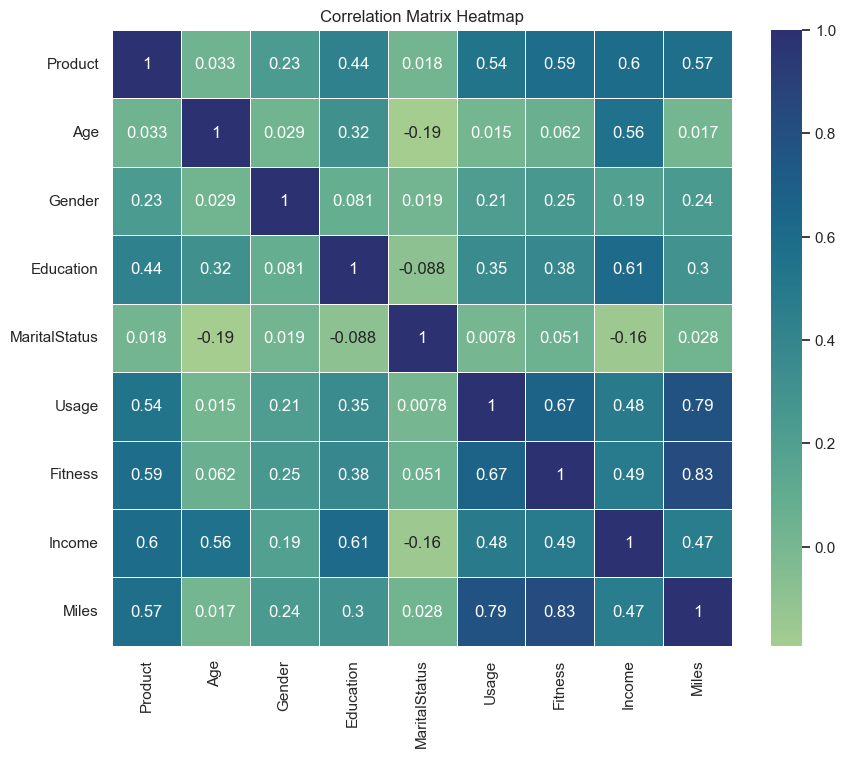

In [317]:
# Encode categorical variables
df['Product'] = df_aerofit['Product'].astype('category').cat.codes
df['Miles'] = df_aerofit['Miles'].astype('category').cat.codes
df['Usage'] = df_aerofit['Usage'].astype('category').cat.codes
df['Age'] = df_aerofit['Age'].astype('category').cat.codes
df['Gender'] = df_aerofit['Gender'].astype('category').cat.codes
df['Education'] = df_aerofit['Education'].astype('category').cat.codes
df['MaritalStatus'] = df_aerofit['MaritalStatus'].astype('category').cat.codes
df['Fitness'] = df_aerofit['Fitness'].astype('category').cat.codes
df['Income'] = df_aerofit['Income'].astype('category').cat.codes

# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='crest', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


## Key Correlation Insights from heatmap
1. **Fitness vs. Usage (Strong Positive Correlation)**
   - Interpretation: Customers who use the product more frequently tend to report higher fitness levels.
   - Business Action:
       - Target fitness-conscious individuals with loyalty or usage-based rewards.
       - Promote the product as a tool for maintaining or improving fitness.

2. **Income vs. Product (Moderate Positive Correlation)**
    - Interpretation: Certain products (e.g., KP781) are more popular among higher-income customers.
    - Business Action:
        - Position premium products for higher-income segments.
        - Use income-based segmentation for personalized marketing.

3. **Education vs. Income (Moderate Positive Correlation)**
    - Interpretation: Higher education levels are associated with higher income.
    - Business Action:
        - Consider educational background when designing campaigns for high-end products.
        - Use education as a proxy for income in targeting when direct income data is unavailable.

4. **Age vs. Income (Moderate Positive Correlation)**
    - Interpretation: Older customers tend to have higher incomes.
    - Business Action:
        - Tailor product messaging for older demographics with a focus on value and quality.
        - Offer financing or premium plans to this group.

5. **Miles vs. Age/Income (Negative Correlation)**
    - Interpretation: Younger or lower-income individuals tend to travel more miles.
    - Business Action:
        - Promote travel-related features or benefits to younger users.
        - Consider bundling offers with travel or mobility services.

# Non-Graphical Analysis

In [318]:
# Function to generate customer profiling for each product
def customer_profiling(df_aerofit, product):
    product_df_aerofit = df_aerofit[df_aerofit['Product'] == product]
    
    age_range = (product_df_aerofit['Age'].min(), product_df_aerofit['Age'].max(), product_df_aerofit['Age'].mean(), product_df_aerofit['Age'].mode())
    gender = product_df_aerofit['Gender'].value_counts(normalize=True) * 100
    marital_status = product_df_aerofit['MaritalStatus'].value_counts(normalize=True) * 100
    income_group = (product_df_aerofit['Income'].min(), product_df_aerofit['Income'].max(), product_df_aerofit['Income'].mean(), product_df_aerofit['Income'].mode())
    education = (product_df_aerofit['Education'].min(), product_df_aerofit['Education'].max())
    
    return age_range, gender,marital_status, income_group, education

# Generate profiling for each product
products = df_aerofit['Product'].unique()
profiling = {}

for product in products:
    profiling[product] = customer_profiling(df_aerofit, product)

# Display the profiling results
for product, profile in profiling.items():
    age_range, gender, marital_status, income_group, education = profile
    print(f"Product: {product}")
    print(f"Age Range: Min- {age_range[0]}, Max- {age_range[1]}, Mean- {age_range[2]}, Mode- {age_range[3][0]}")
    print("Gender Distribution:")
    print(gender)
    print("Marital Status Distribution:")
    print(marital_status)
    print(f"Annual Income Group (in $): Min- {income_group[0]}, Max- {income_group[1]}, Mean- {income_group[2]}, Mode- {income_group[3][0]}")
    print(f"Education Group: {education[0]} - {education[1]}")
    print("\n")


Product: KP281
Age Range: Min- 18, Max- 50, Mean- 28.55, Mode- 23
Gender Distribution:
Gender
Male      50.0
Female    50.0
Name: proportion, dtype: float64
Marital Status Distribution:
MaritalStatus
Partnered    60.0
Single       40.0
Name: proportion, dtype: float64
Annual Income Group (in $): Min- 29562, Max- 68220, Mean- 46418.025, Mode- 46617
Education Group: 12 - 18


Product: KP481
Age Range: Min- 19, Max- 48, Mean- 28.9, Mode- 25
Gender Distribution:
Gender
Male      51.666667
Female    48.333333
Name: proportion, dtype: float64
Marital Status Distribution:
MaritalStatus
Partnered    60.0
Single       40.0
Name: proportion, dtype: float64
Annual Income Group (in $): Min- 31836, Max- 67083, Mean- 48973.65, Mode- 45480
Education Group: 12 - 18


Product: KP781
Age Range: Min- 22, Max- 48, Mean- 29.1, Mode- 25
Gender Distribution:
Gender
Male      82.5
Female    17.5
Name: proportion, dtype: float64
Marital Status Distribution:
MaritalStatus
Partnered    57.5
Single       42.5
Nam

**Calculated:**
- Age range (min, max, mean, mode)
- Gender distribution (as percentages)
- Marital Status distribution (as percentages)
- Annual Income range (min, max, mean, mode)
- Education range (min, max) 
Prints a clean summary for each product.

## **Representing the Probability**
*1. Percent of customers have purchased KP281, KP481, or KP781*

In [319]:
df_products = products_counts.to_frame().reset_index()
print(df_products)

  Product   0
0   KP281  80
1   KP481  60
2   KP781  40


In [320]:
total_count = df_aerofit.shape[0]
for product, count in products_counts.items():
    prob = (count/total_count)*100
    print(f"Probability percentage of purchasing {product}: {prob}")


Probability percentage of purchasing KP281: 44.44444444444444
Probability percentage of purchasing KP481: 33.33333333333333
Probability percentage of purchasing KP781: 22.22222222222222


In [321]:
products = df_aerofit['Product'].unique()
products

crosstab = pd.crosstab(df_aerofit['Product'], df_aerofit['Gender'])
crosstab

Gender,Female,Male
Product,,
KP281,40,40
KP481,29,31
KP781,7,33


In [322]:

df_males = df_aerofit[df_aerofit['Gender']=='Male']
df_females = df_aerofit[df_aerofit['Gender']=='Female']

Males_count = df_males['Gender'].value_counts()
Females_count = df_females['Gender'].value_counts()

for index, row in crosstab.iterrows():
    print(f"Product: {index}")
    
    ## Probability to purchase KP781 given the customer is a Male
    prob_male = row[1]/Males_count[0]
    prob_male = round(prob_male,2)
    print(f"Probability to purchase {index} given the customer is a Male: {prob_male}")
    
    ## Probability to purchase KP781 given the customer is a Female
    prob_female = row[0]/Females_count[0]
    prob_female = round(prob_female,2)
    print(f"Probability to purchase {index} given the customer is a Female: {prob_female}")
    print("\n")


Product: KP281
Probability to purchase KP281 given the customer is a Male: 0.38
Probability to purchase KP281 given the customer is a Female: 0.53


Product: KP481
Probability to purchase KP481 given the customer is a Male: 0.3
Probability to purchase KP481 given the customer is a Female: 0.38


Product: KP781
Probability to purchase KP781 given the customer is a Male: 0.32
Probability to purchase KP781 given the customer is a Female: 0.09




C:\Users\njain121\AppData\Local\Temp\ipykernel_11676\3196196106.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prob_male = row[1]/Males_count[0]
C:\Users\njain121\AppData\Local\Temp\ipykernel_11676\3196196106.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prob_female = row[0]/Females_count[0]


### Insights:
- Among all female customers in the dataset, about 53% chose the KP281 model.
- Among all male customers in the dataset, about 38% chose the KP281 model and 32% chose KP781.


In [323]:
## The probability that a customer uses the treadmill 4 or more times per week

cust_usage_4_more = df_aerofit[df_aerofit['Usage'] >=4]
prob_usage_4_more = cust_usage_4_more.shape[0]/df_aerofit.shape[0]
prob_usage_4_more*100

43.333333333333336

### Insights: Probability of High Usage
- The probability that a customer uses the treadmill 4 or more times per week is 43.3%.
- This suggests a significant portion of customers are highly engaged, which is a strong selling point.

# Conclusive Insights:
    - **KP281:** A versatile, balanced product ideal for a broad audience—young to middle-aged, moderate income, and both genders.
    - **KP481:** Appeals to middle-income, younger users, but shows lower satisfaction.
    - **KP781:** A premium, high-performance model favored by high-income, fitness-focused males.

### Cross-Product Business Insights
    - **Usage & Engagement**
        - 43.3% of customers use the treadmill 4+ times/week.
        - Strong opportunity to promote loyalty programs or usage-based rewards.
    - **Fitness vs. Usage Correlation**
        - Promote treadmills as tools for fitness improvement.
    - **Income & Product Correlation**
        - KP781 aligns with higher-income customers.
        - KP281 and KP481 serve low to mid-income segments.
        - Use income-based segmentation for personalized offers.
    - **Education**
        - Higher education correlates with higher income.
        - Use education level in targeting when income data is unavailable.
    - **Demographic-Based advice**
        - Younger users: Emphasize style, innovation, and affordability.
        - Older users: Focus on comfort, quality, and financing options.

# Business Strategies:
    - ***KP781 – The Premium Performer***
        - Market as a high-performance, premium product.
        - Target fitness enthusiasts, athletes, and high-income professionals.
        - Use luxury branding, influencer marketing, and fitness partnerships.
        - Promote features like durability, advanced tracking, and smart connectivity.        
        - Address female adoption gap with inclusive design and messaging.
        
    - ***KP281 – The Versatile All-Rounder***
        - Position as a flagship product for general fitness needs.
        - Emphasize value, reliability, and comfort.
        - Use broad marketing channels (TV, email, social media).
        - Highlight gender-neutral appeal and family-friendly features.
        - Ideal for first-time buyers or budget-conscious customers.
        
    - ***KP481 – The Balanced Mid-Tier Option***
        - Reposition or improve based on lower fitness satisfaction.
        - Focus on middle-income, younger adults.
        - Highlight ease of use, affordability, and compact design.
        - Gather customer feedback to refine features or marketing.
        - Use targeted promotions for singles and small households.
    
